单个cell的前向传播

In [3]:
import numpy as np

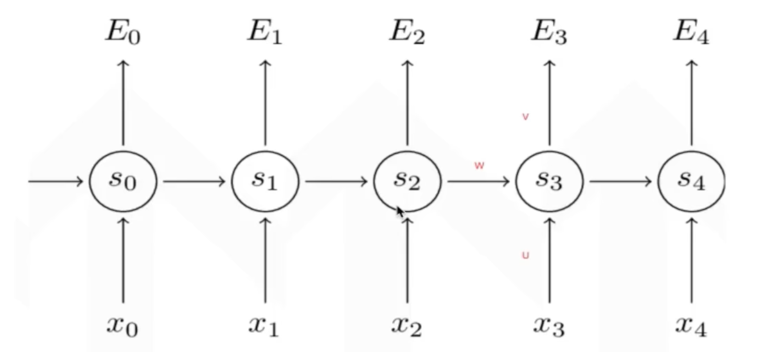

$$
s_t = tanh(U * x_t + W * s_{t-1} + b_a)
$$
$$
o_t = softmax(V * s_t + b_y)
$$

In [6]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def rnn_cell_forward(x_t,s_prev,parameters):
    """
    单个cell的前向传播
    :param x_t: 当前t时刻的序列输入
    :param s_prev: 上一个cell的隐层状态输入
    :param parameters: cell中的参数
    :return: 隐层输出 s_next, out_pred
    """

    # 取出参数
    U = parameters["U"]
    W = parameters["W"]
    V = parameters["V"]
    ba = parameters["ba"]
    by = parameters["by"]

    # 根据公式计算
    # 隐层的输出计算
    s_next = np.tanh(np.dot(U,x_t) + np.dot(W, s_prev) + ba)

    # 计算cell的输出
    out_pred = softmax(np.dot(V,s_next) + by)

    # 记录每一层的值，用于反向传播
    cache = (s_next, s_prev, x_t, parameters)

    return s_next,out_pred,cache

测试 m=3是单词的个数，n=5为自定义的数字

In [7]:
np.random.seed(1)

x_t = np.random.rand(3,1)       # 当前序列的输入，因为是只有3个词，所以维度是3
s_prev = np.random.rand(5,1)    # 前一个隐层s传过来的值，U定义为5*3，自定义的数为5，所以这里是5*1

U = np.random.rand(5,3)
W = np.random.rand(5,5)         # s过来的是一个5*1的，所以W是5*5

V = np.random.rand(3,5)         # 隐层的数值乘以V之后输出，当作loss，所以应该和y的维度一样，应该是3*5，这样乘以5*1的s之后才能变成3*1
ba = np.random.rand(5,1)        # x那里过来的，U * x_t
by = np.random.rand(3,1)        # 一起经过tanh之后到上面loss，V * s_t

parameters = {"U":U,"W":W,"V":V,"ba":ba,"by":by}

s_next, out_pred, cache = rnn_cell_forward(x_t,s_prev,parameters)
print("s_next:",s_next)
print("s_next.shape",s_next.shape)
print("out_pred:",out_pred)
print("out_pred.shape",out_pred.shape)


s_next: [[0.88911409]
 [0.79387346]
 [0.94004845]
 [0.89392268]
 [0.97115073]]
s_next.shape (5, 1)
out_pred: [[0.22243827]
 [0.17932275]
 [0.59823898]]
out_pred.shape (3, 1)


所有的cell前向传播

In [9]:
def rnn_forward(x, s0, parameters):
    """
    对于所有cell进行前向传播
    :param x: 输入序列，形状（m，1，T），T为序列长度
    :param s0: 初始状态输入，0
    :param parameters: 所有cell共享的参数，U，W，V，ba，by
    :return: s，y，caches
    """
    caches = []

    # 获取序列的长度（时刻数）
    m, _, T = x.shape

    # 获取输入的N，定义隐层输出大小状态
    m, n = parameters["V"].shape

    # 获取s0的值，保存到s_next里面，以便于前向传播传入到cell
    s_next = s0

    # 定义s，y保留所有cell的隐层状态以及输出
    s = np.zeros((n, 1, T))
    y = np.zeros((m, 1, T))     # 保存所有层的cell的输出

    # 循环对每一个cell进行前向传播
    for t in range(T):
        # 对于t时刻的cell，进行输入输出
        s_next, out_pred, cache = rnn_cell_forward(x[:,:,t], s_next, parameters)

        # 放入数组当中
        s[:,:,t] = s_next
        y[:,:,t] = out_pred

        # 放入所有的缓存到列表
        caches.append(cache)

    return s, y, caches

In [7]:
np.random.seed(1)

# 定义了4个cell，每个词形状(3,1)      m = 3, n = 5（n为自己定义的）
x = np.random.rand(3,1,4)
s0 = np.random.rand(5,1)

W = np.random.rand(5,5)
U = np.random.rand(5,3)
V = np.random.rand(3,5)
ba = np.random.rand(5,1)
by = np.random.rand(3,1)
parameters = {"U":U,"W":W,"V":V,"ba":ba,"by":by}

s,y,caches = rnn_forward(x,s0,parameters)
print("s:",s)
print("s.shape",s.shape)

print("y:",y)
print("y.shape",y.shape)

s: [[[0.921197   0.99488486 0.99489947 0.99682437]]

 [[0.98847559 0.99922556 0.99922328 0.99962034]]

 [[0.74750958 0.96377568 0.96432242 0.97144854]]

 [[0.94315366 0.99882457 0.99806623 0.99895849]]

 [[0.98789449 0.99980403 0.99974595 0.99986317]]]
s.shape (5, 1, 4)
y: [[[0.12815123 0.1276013  0.12767508 0.12774178]]

 [[0.31657441 0.29245542 0.29242263 0.29163196]]

 [[0.55527436 0.57994328 0.57990228 0.58062625]]]
y.shape (3, 1, 4)


单个cell的反向传播

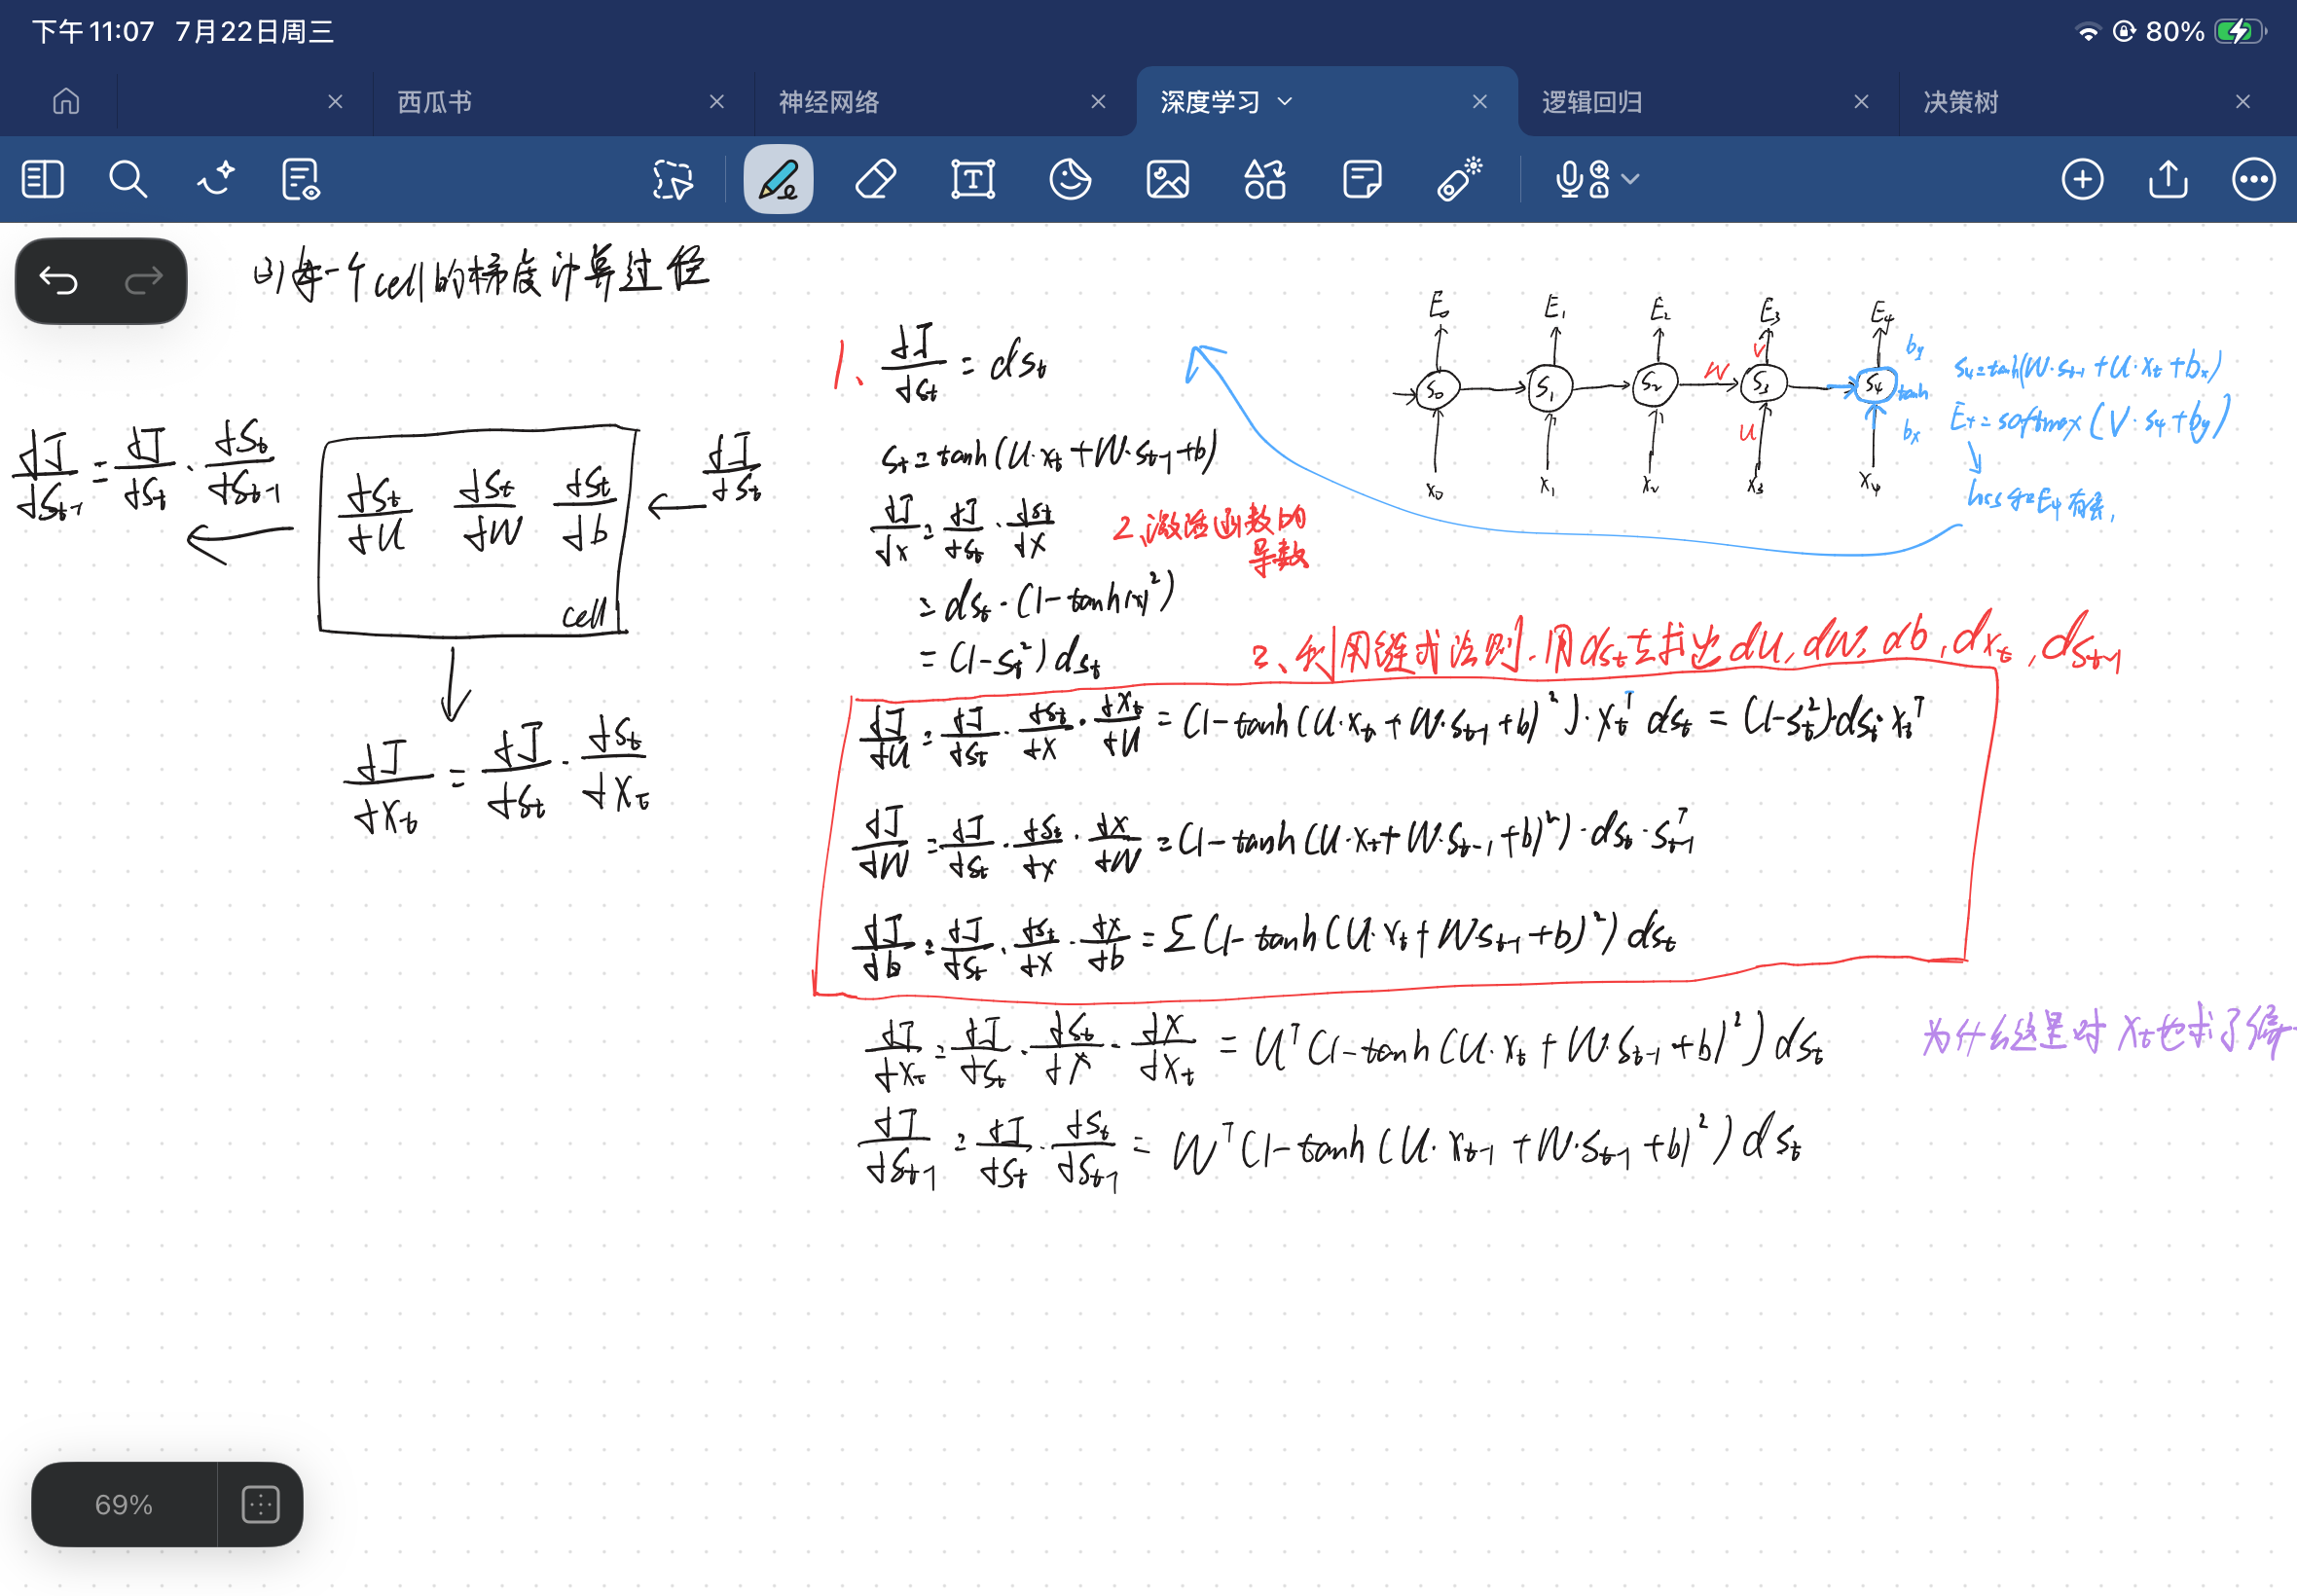

In [ ]:
"""
ds_next: 表示当前cell的损失对输出s_t的导数
dtanh: 表示当前cell的损失对激活函数的导数
dx_t: 表示当前cell的损失对输出x_t的导数
dU: 表示当前cell的损失对U的导数
ds_prev: 表示当前cell的损失对上一个cell的输入的导数
dW: 表示当前cell的损失对W的导数
dba: 表示当前cell的损失对ba的导数
"""

In [12]:
def rnn_cell_backward(ds_next, cache):
    """
    每个cell的右边输入梯度
    :param ds_next: s_next的梯度值
    :param cache: 当前cell的缓存
    :return: gradients  该cell的6个梯度
    """

    # 获取cache当中的缓存值以及参数
    s_next, s_prev, x_t, parameters = cache

    U = parameters["U"]
    W = parameters["W"]
    # V = parameters["V"]
    # ba = parameters["ba"]
    # by = parameters["by"]

    # 根据公式进行反向传播计算
    # 1. 计算tanh的导数
    dtanh = (1 - s_next ** 2) * ds_next

    # 2. 计算U的梯度值
    dU = np.dot(dtanh, x_t.T)

    # 3. 计算W的梯度
    dW = np.dot(dtanh, s_prev.T)

    # 4. 计算ba的梯度值
    # 保持计算之后的维度不变
    dba = np.sum(dtanh, axis=1, keepdims=True)

    # 5. 计算x_t的导数
    dx_t = np.dot(U.T, dtanh)

    # 6. 计算s_prev的导数
    ds_prev = np.dot(W.T, dtanh)

    # 把所有的导数保存到字典当中返回
    gradients = {"dtanh":dtanh, "dU":dU, "dW":dW, "dba":dba, "dx_t":dx_t, "ds_prev":ds_prev}
    return gradients


所有cell反向传播

In [15]:
def rnn_backward(ds,caches):
    """
    所有cell的反向传播过程
    :param ds: 每个时刻的损失对于s的梯度值（假设已知的），（5，1，4）
    :param caches: 每个cell的输出值
    :return:
    """
    # 取出cache当中的值
    s1, s0, x_1, parameters = caches[0]

    # 获取输入数据的总共序列长度
    n, _, T = ds.shape
    m, _ = x_1.shape

    # 存储所有一次更新后的参数和梯度值
    dU = np.zeros((n, m))
    dW = np.zeros((n, n))
    dba = np.zeros((n,1))


    # 初始化一个为0大第二部分梯度值
    ds_prevt = np.zeros((n, 1))

    # 保存其他不需要更新的梯度
    dx = np.zeros((m,1,T))

    # 循环从后往前进行计算梯度
    for t in reversed(range(T)):
        # 假设从3时刻开始
        # 2，1，0时刻的s梯度由两个部分组成
        gradients = rnn_cell_backward(ds[:,:,t] + ds_prevt, caches[t])

        ds_prevt = gradients["ds_prev"]

        # u, w, ba, x_t, s_prev
        # 共享参数需要相加
        dU += gradients["dU"]
        dW += gradients["dW"]
        dba += gradients["dba"]

        # 保存每一层的x_t, s_prev的梯度值
        dx[:,:,t] = gradients["dx_t"]

    # 返回所有更新参数的梯度以及其他变量的梯度值
    gradients = {"dU":dU, "dW":dW, "dba":dba, "dx":dx}
    return gradients

In [16]:
np.random.seed(1)

x = np.random.randn(3,1,4)
s0 = np.random.randn(5,1)

W = np.random.randn(5,5)
U = np.random.rand(5,3)
V = np.random.randn(3,5)
ba = np.random.rand(5,1)
by = np.random.rand(3,1)
parameters = {"U":U,"W":W,"V":V,"ba":ba,"by":by}

s,y,caches = rnn_forward(x,s0,parameters)
ds = np.random.randn(5,1,4)

gradients = rnn_backward(ds,caches)
print(gradients)

{'dU': array([[-0.61359467, -1.81262838, -0.49621413],
       [-1.56508771, -3.69290817, -0.21613458],
       [-0.00931669,  0.02992933,  0.02774175],
       [-0.39849752, -0.20623805, -0.08096311],
       [-1.39335361,  0.57911417,  0.2013756 ]]), 'dW': array([[ 8.89085686e-01,  8.55349192e-01,  8.90998412e-01,
         8.15241038e-01,  7.91094637e-01],
       [ 1.73672850e+00,  2.00700423e+00,  1.63255777e+00,
         1.44057987e+00,  2.28381202e+00],
       [-1.22901606e-02,  1.68983497e-03, -1.49012441e-02,
        -1.88381765e-02,  1.89545235e-02],
       [ 7.77662653e-02,  9.26836147e-02, -2.79181325e-01,
         2.68470558e-01,  4.05592044e-02],
       [ 1.63949480e-01,  7.84066430e-01, -1.16024992e-01,
        -1.35393627e-01,  1.49141439e+00]]), 'dba': array([[ 0.89611654],
       [ 2.50070214],
       [ 0.02382206],
       [-0.24575126],
       [ 1.95413465]]), 'dx': array([[[-0.02885311,  1.65155309,  0.66245316,  0.44305931]],

       [[-0.02862301,  1.60596337,  0.470634